# 02 Rouge And Heuristic Metrics

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `02-rouge-and-heuristic-metrics.ipynb`

In [ ]:
# !pip install rouge-score
# !pip install nltk
# !pip install pandas

In [4]:
# ==========================================
# Notebook 02
# ROUGE and Heuristic Metrics
# ==========================================

import pandas as pd
import numpy as np

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from rouge_score import rouge_scorer

In [5]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [6]:
reference = "AWS is Amazon Web Services, a cloud computing platform."

prediction = "AWS is Amazon's cloud platform."

In [7]:
def exact_match(prediction, reference):

    return int(prediction.strip().lower() == reference.strip().lower())

In [8]:
exact_match(prediction, reference)

0

In [9]:
exact_match(reference, reference)

1

In [10]:
def compute_bleu(prediction, reference):

    smoothie = SmoothingFunction().method1

    score = sentence_bleu(
        [reference.split()], prediction.split(), smoothing_function=smoothie
    )

    return score

In [11]:
compute_bleu(prediction, reference)

0.060713336587447424

In [12]:
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

In [13]:
scores = rouge.score(reference, prediction)

scores

{'rouge1': Score(precision=0.8333333333333334, recall=0.5555555555555556, fmeasure=0.6666666666666667),
 'rouge2': Score(precision=0.4, recall=0.25, fmeasure=0.3076923076923077),
 'rougeL': Score(precision=0.8333333333333334, recall=0.5555555555555556, fmeasure=0.6666666666666667)}

In [14]:
def compute_rouge(prediction, reference):

    scores = rouge.score(reference, prediction)

    return {
        "rouge1": scores["rouge1"].fmeasure,
        "rouge2": scores["rouge2"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure,
    }

In [15]:
compute_rouge(prediction, reference)

{'rouge1': 0.6666666666666667,
 'rouge2': 0.3076923076923077,
 'rougeL': 0.6666666666666667}

In [16]:
def heuristic_evaluation(prediction, reference):

    bleu = compute_bleu(prediction, reference)

    rouge_scores = compute_rouge(prediction, reference)

    em = exact_match(prediction, reference)

    return {"exact_match": em, "bleu": bleu, **rouge_scores}

In [17]:
heuristic_evaluation(prediction, reference)

{'exact_match': 0,
 'bleu': 0.060713336587447424,
 'rouge1': 0.6666666666666667,
 'rouge2': 0.3076923076923077,
 'rougeL': 0.6666666666666667}

In [18]:
results = []

In [19]:
for _, row in df.iterrows():

    score = heuristic_evaluation(row["generated_response"], row["ground_truth"])

    results.append(score)

In [20]:
results_df = pd.DataFrame(results)

results_df.head()

,exact_match,bleu,rouge1,rouge2,rougeL
0,0,0.060713,0.666667,0.307692,0.666667
1,0,0.046258,0.500000,0.142857,0.375000
2,0,0.090574,0.666667,0.200000,0.666667
3,0,0.057951,0.400000,0.000000,0.400000
4,0,0.057951,0.400000,0.000000,0.400000


In [21]:
evaluation_df = pd.concat([df, results_df], axis=1)

In [22]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,exact_match,bleu,rouge1,rouge2,rougeL
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0,0.060713,0.666667,0.307692,0.666667
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0,0.046258,0.500000,0.142857,0.375000
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0,0.090574,0.666667,0.200000,0.666667
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0,0.057951,0.400000,0.000000,0.400000
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0,0.057951,0.400000,0.000000,0.400000


In [23]:
evaluation_df[["exact_match", "bleu", "rouge1", "rouge2", "rougeL"]].mean()

exact_match    0.000000
bleu           0.096489
rouge1         0.406667
rouge2         0.062527
rougeL         0.400417
dtype: float64

In [24]:
def quality_status(rouge_l):

    if rouge_l >= 0.8:
        return "Excellent"

    elif rouge_l >= 0.6:
        return "Good"

    elif rouge_l >= 0.4:
        return "Average"

    return "Poor"

In [25]:
evaluation_df["quality"] = evaluation_df["rougeL"].apply(quality_status)

In [26]:
evaluation_df[["question", "rougeL", "quality"]]

,question,rougeL,quality
0,What is AWS?,0.666667,Good
1,What is Azure?,0.375000,Poor
2,What is Google Cloud?,0.666667,Good
3,What is AWS?,0.400000,Average
4,What is Azure?,0.400000,Average
5,What is Google Cloud?,0.500000,Average
6,What is Oracle Cloud?,0.500000,Average
7,What is IBM Cloud?,0.500000,Average
8,Question 8,0.333333,Poor
9,Question 9,0.333333,Poor


In [28]:
evaluation_df.to_csv("../evaluation_results/heuristic_scores.csv", index=False)

In [29]:
reference = "The application works perfectly"

prediction = "The software functions brilliantly"

In [30]:
heuristic_evaluation(prediction, reference)

{'exact_match': 0,
 'bleu': 0.08034284189446518,
 'rouge1': 0.25,
 'rouge2': 0.0,
 'rougeL': 0.25}

In [31]:
import matplotlib.pyplot as plt

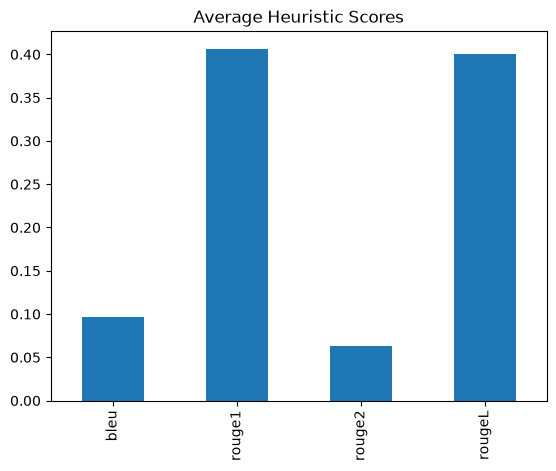

In [32]:
evaluation_df[["bleu", "rouge1", "rouge2", "rougeL"]].mean().plot(kind="bar")

plt.title("Average Heuristic Scores")

plt.show()